In [6]:
# AI Mental Health Support Analyzer

# Author: Prathima
# Project: AI Mental Health Streamlit App
# Goal: End-to-End AI Pipeline Demonstration

In [8]:
!pip install pandas numpy matplotlib seaborn scikit-learn wordcloud pillow

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [15]:
df = pd.read_csv("dataset/mental_health.csv")

df.head()

,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


In [16]:
df.shape

(7731, 2)

In [23]:
print("Columns in dataset:")

print(df.columns)

Columns in dataset:
Index(['clean_text', 'is_depression'], dtype='object')


In [24]:
# Standardizing column names

if len(df.columns) >= 2:

    df = df.iloc[:, :2]

    df.columns = ["text", "label"]

print(df.head())

                                                text  label
0  we understand that most people who reply immed...      1
1  welcome to r depression s check in post a plac...      1
2  anyone else instead of sleeping more when depr...      1
3  i ve kind of stuffed around a lot in my life d...      1
4  sleep is my greatest and most comforting escap...      1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7731 entries, 0 to 7730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    7731 non-null   object
 1   label   7731 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 120.9+ KB


In [26]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [27]:
df = df.dropna()
df.shape

(7731, 2)

In [28]:
df["label"].value_counts()

0    3900
1    3831
Name: label, dtype: int64

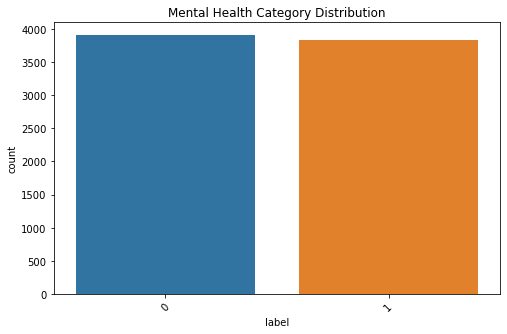

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(x="label", data=df)

plt.title("Mental Health Category Distribution")

plt.xticks(rotation=45)

plt.show()

In [31]:
def clean_text(text):

    text = str(text)
    text = text.lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = text.strip()

    return text

In [32]:
df["clean_text"] = df["text"].apply(clean_text)

df.head()

,text,label,clean_text
0,we understand that most people who reply immed...,1,we understand that most people who reply immed...
1,welcome to r depression s check in post a plac...,1,welcome to r depression s check in post a plac...
2,anyone else instead of sleeping more when depr...,1,anyone else instead of sleeping more when depr...
3,i ve kind of stuffed around a lot in my life d...,1,i ve kind of stuffed around a lot in my life d...
4,sleep is my greatest and most comforting escap...,1,sleep is my greatest and most comforting escap...


WordCloud failed due to font issue.
Error: Only supported for TrueType fonts


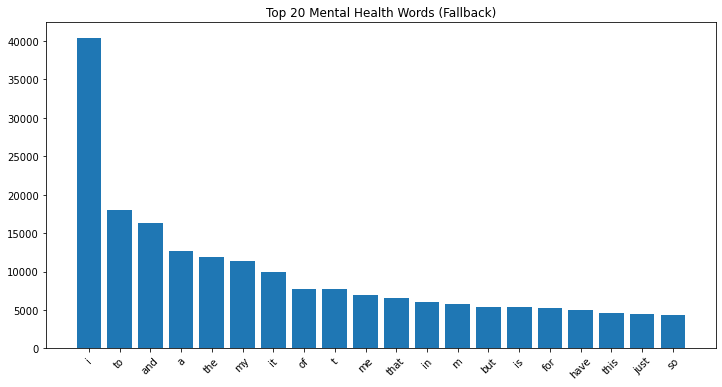

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os

# Ensure clean_text column exists
if "clean_text" not in df.columns:
    
    def clean_text(text):
        import re
        import string
        
        text = str(text)
        text = text.lower()
        text = re.sub(r"http\S+", "", text)
        text = re.sub(r"\d+", "", text)
        text = text.translate(str.maketrans("", "", string.punctuation))
        text = text.strip()
        return text

    df["clean_text"] = df["text"].apply(clean_text)

# Remove null values
df = df.dropna(subset=["clean_text"])

# Convert to string
df["clean_text"] = df["clean_text"].astype(str)

# Join all text
text_data = " ".join(df["clean_text"].tolist())

# Try to load font
font_path = None

windows_font = "C:/Windows/Fonts/arial.ttf"
linux_font = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"

if os.path.exists(windows_font):
    font_path = windows_font
elif os.path.exists(linux_font):
    font_path = linux_font

# Generate wordcloud
try:
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=200,
        font_path=font_path
    ).generate(text_data)

    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title("Mental Health Word Cloud", fontsize=15)
    plt.show()

except Exception as e:
    
    print("WordCloud failed due to font issue.")
    print("Error:", e)

    # Fallback visualization
    from collections import Counter

    words = text_data.split()
    word_freq = Counter(words).most_common(20)

    words = [w[0] for w in word_freq]
    counts = [w[1] for w in word_freq]

    plt.figure(figsize=(12,6))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title("Top 20 Mental Health Words (Fallback)")
    plt.show()

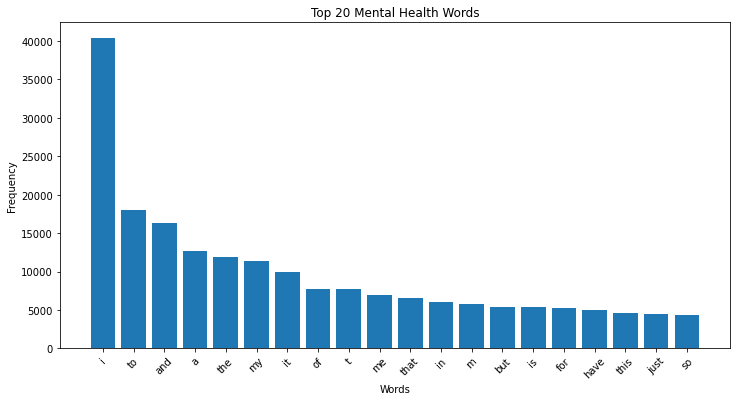

In [72]:
from collections import Counter
import matplotlib.pyplot as plt

# Ensure clean_text exists
if "clean_text" not in df.columns:
    raise ValueError("clean_text column not found")

# Join words
words = " ".join(df["clean_text"].astype(str)).split()

# Count frequency
word_freq = Counter(words)

top_words = word_freq.most_common(20)

# Separate words and counts
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# Plot
plt.figure(figsize=(12,6))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Mental Health Words")

plt.show()

In [46]:
encoder = LabelEncoder()

df["label_encoded"] = encoder.fit_transform(
    df["label"]
)

df.head()

,text,label,clean_text,label_encoded
0,we understand that most people who reply immed...,1,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1,sleep is my greatest and most comforting escap...,1


In [47]:
label_map = dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
)

label_map

{0: 0, 1: 1}

In [59]:
X = df["clean_text"]

y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
tfidf = TfidfVectorizer(

    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [61]:
model = LogisticRegression(max_iter=1000)

model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [62]:
predictions = model.predict(
    X_test_tfidf
)

In [63]:
accuracy_score(
    y_test,
    predictions
)

0.9599224305106658

In [65]:
try:
    
    target_names = list(map(str, encoder.classes_))

    report = classification_report(
        y_test,
        predictions,
        target_names=target_names
    )

    print("\nClassification Report\n")
    print(report)

except Exception as e:
    
    print("Error in classification report:", e)

    print(
        classification_report(
            y_test,
            predictions
        )
    )


Classification Report

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       780
           1       0.98      0.94      0.96       767

    accuracy                           0.96      1547
   macro avg       0.96      0.96      0.96      1547
weighted avg       0.96      0.96      0.96      1547



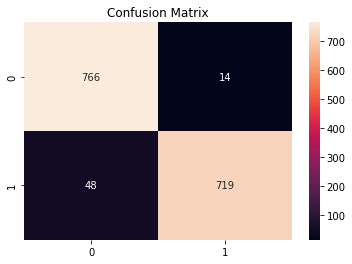

In [66]:
cm = confusion_matrix(
    y_test,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

In [68]:
import pickle

os.makedirs("model", exist_ok=True)

pickle.dump(
    model,
    open(
        "model/mental_health_model.pkl",
        "wb"
    )
)

pickle.dump(
    encoder,
    open(
        "model/label_encoder.pkl",
        "wb"
    )
)

pickle.dump(
    tfidf,
    open(
        "model/tfidf.pkl",
        "wb"
    )
)

In [69]:
df.to_csv(
    "model/processed_data.csv",
    index=False
)

In [70]:
sample = "I feel very stressed and depressed"

sample_clean = clean_text(sample)

sample_vector = tfidf.transform([sample_clean])

prediction = model.predict(sample_vector)

encoder.inverse_transform(prediction)

array([1], dtype=int64)

In [71]:
print("AI Mental Health Model Built Successfully")

AI Mental Health Model Built Successfully
